In [2]:
!pip install albumentations
!git clone https://github.com/alexgkendall/SegNet-Tutorial.git

Cloning into 'SegNet-Tutorial'...
remote: Enumerating objects: 2785, done.
remote: Total 2785 (delta 0), reused 0 (delta 0), pack-reused 2785 (from 1)
Receiving objects: 100% (2785/2785), 340.84 MiB | 33.75 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [3]:
%%writefile model.py
"""
Project: Semantic Segmentation for Autonomous Driving (CamVid).
Model: U-Net Architecture with Skip Connections.
"""
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """
    FUNCTION: Performs two consecutive 3x3 convolutions.
    RATIONALE: Consolidates spatial features and stabilizes learning via Batch Normalization.
    """
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False), # Spatial feature extraction
            nn.BatchNorm2d(out_c),                       # Covariate shift reduction
            nn.ReLU(inplace=True),                       # Non-linear activation
            nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    """
    FUNCTION: Symmetric Encoder-Decoder for pixel-wise classification.
    INTERFACE: Input [N, 3, H, W] -> Output [N, Classes, H, W].
    """
    def __init__(self, in_channels=3, out_channels=32):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        features = [64, 128, 256, 512]

        # ENCODER: Downsampling path to capture context
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # DECODER: Upsampling path to enable precise localization
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(512, 1024)
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x) # Store for spatial reconstruction
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # DECODER STAGE: Concatenate skip connections with upsampled maps
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_connection = skip_connections[i//2]
            concat_skip = torch.cat((skip_connection, x), dim=1) # Dimensionality alignment
            x = self.ups[i+1](concat_skip)

        return self.final_conv(x)

Writing model.py


In [4]:
%%writefile data_setup.py
"""
Dataset: Cambridge-driving Labeled Video Database (CamVid).
Strategy: Synchronized Stochastic Geometric Transformation.
"""
import os
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

class CamVidDataset(Dataset):
    """
    INTERFACE: Maps file indices to (image, mask) tensor pairs.
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir, self.mask_dir = img_dir, mask_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, index):
        # FAST-IO: Load via OpenCV
        img_path = os.path.join(self.img_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.masks[index])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # SYNCHRONIZED TRANSFORM: Ensures mask and image warp identically
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        return image, mask.long()

def get_loaders(batch_size=8):
    """
    SPECIFICATION: Implements ImageNet normalization and geometric regularization.
    """
    train_transform = A.Compose([
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    val_transform = A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    train_ds = CamVidDataset('SegNet-Tutorial/CamVid/train/', 'SegNet-Tutorial/CamVid/trainannot/', train_transform)
    val_ds = CamVidDataset('SegNet-Tutorial/CamVid/test/', 'SegNet-Tutorial/CamVid/testannot/', val_transform)

    # THROUGHPUT: num_workers and pin_memory for optimal GPU saturation
    return DataLoader(train_ds, batch_size, shuffle=True, num_workers=2, pin_memory=True), \
           DataLoader(val_ds, batch_size, shuffle=False, num_workers=2, pin_memory=True)

Writing data_setup.py


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


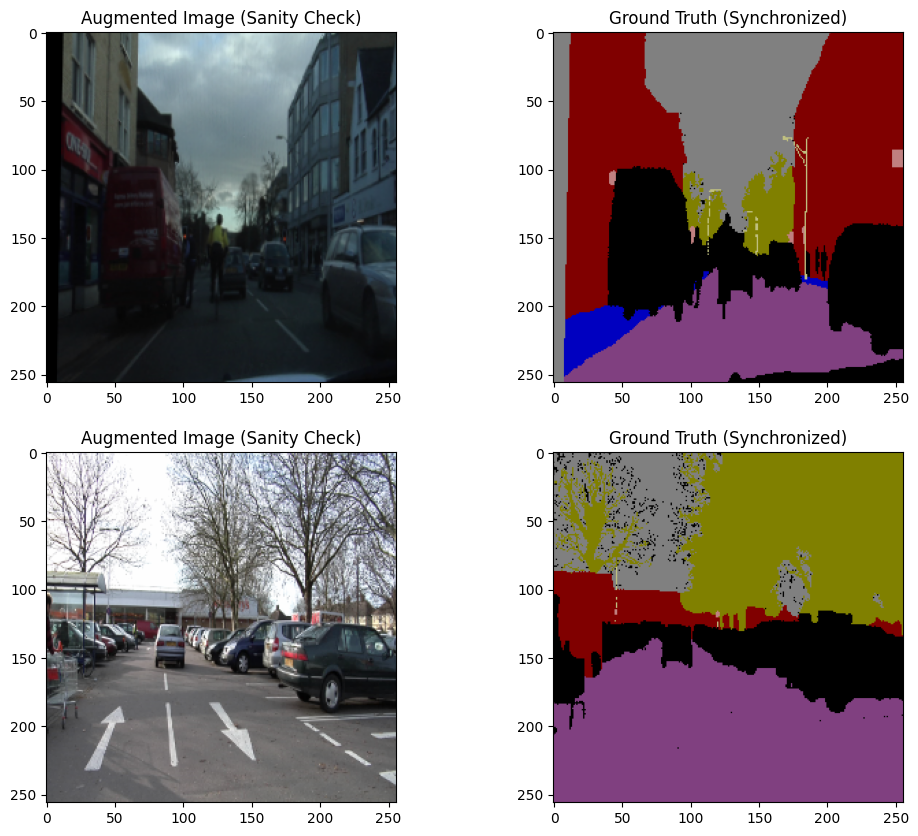

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from data_setup import get_loaders

def color_label(mask):
    """Map indices to RGB colors for human-readable visual inspection."""
    color_map = np.array([[128,128,128], [128,0,0], [192,192,128], [128,64,128], [0,0,192], [128,128,0], [192,128,128], [64,64,128]])
    h, w = mask.shape
    img = np.zeros((h, w, 3), dtype=np.uint8)
    for i in range(len(color_map)):
        img[mask == i] = color_map[i]
    return img

# EXECUTION: Pre-training data verification
train_loader, val_loader = get_loaders(batch_size=4)
images, masks = next(iter(train_loader))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i in range(2):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Augmented Image (Sanity Check)")
    axes[i, 1].imshow(color_label(masks[i].numpy()))
    axes[i, 1].set_title("Ground Truth (Synchronized)")
plt.show()

In [6]:
"""
TRAINING PROTOCOL: Hybrid Stochastic Optimization.
RATIONALE: Dice Loss optimizes for IoU, CrossEntropy optimizes for pixel confidence.
"""
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from model import UNet

class DiceLoss(nn.Module):
    """
    METRIC: 1 - Dice Coefficient.
    RATIONALE: Direct optimization of the spatial overlap metric.
    """
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = torch.nn.functional.one_hot(targets, 32).permute(0, 3, 1, 2).float()
        intersection = (probs * targets_one_hot).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        return 1 - ((2. * intersection + self.smooth) / (union + self.smooth)).mean()

DEVICE = "cuda"
model = UNet(out_channels=32).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
dice_fn = DiceLoss()
scaler = GradScaler() # PERFORMANCE: 16-bit Precision Scaler

print("🚀 SOTA Training Initialized...")
for epoch in range(20):
    model.train()
    loss_epoch = 0
    for data, targets in train_loader:
        data, targets = data.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()

        # AMP: Mixed Precision context for accelerated compute
        with autocast(device_type=DEVICE):
            out = model(data)
            loss = criterion(out, targets) + dice_fn(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_epoch += loss.item()
    print(f"Epoch {epoch+1}/20 | Loss Vector: {loss_epoch/len(train_loader):.4f}")

torch.save(model.state_dict(), "unet_camvid_sota.pth")

🚀 SOTA Training Initialized...
Epoch 1/20 | Loss Vector: 3.3000
Epoch 2/20 | Loss Vector: 2.6009
Epoch 3/20 | Loss Vector: 2.2451
Epoch 4/20 | Loss Vector: 2.0190
Epoch 5/20 | Loss Vector: 1.8465
Epoch 6/20 | Loss Vector: 1.7590
Epoch 7/20 | Loss Vector: 1.6449
Epoch 8/20 | Loss Vector: 1.6140
Epoch 9/20 | Loss Vector: 1.5406
Epoch 10/20 | Loss Vector: 1.4887
Epoch 11/20 | Loss Vector: 1.4722
Epoch 12/20 | Loss Vector: 1.4582
Epoch 13/20 | Loss Vector: 1.4058
Epoch 14/20 | Loss Vector: 1.3802
Epoch 15/20 | Loss Vector: 1.3475
Epoch 16/20 | Loss Vector: 1.3418
Epoch 17/20 | Loss Vector: 1.3356
Epoch 18/20 | Loss Vector: 1.3186
Epoch 19/20 | Loss Vector: 1.2934
Epoch 20/20 | Loss Vector: 1.2749


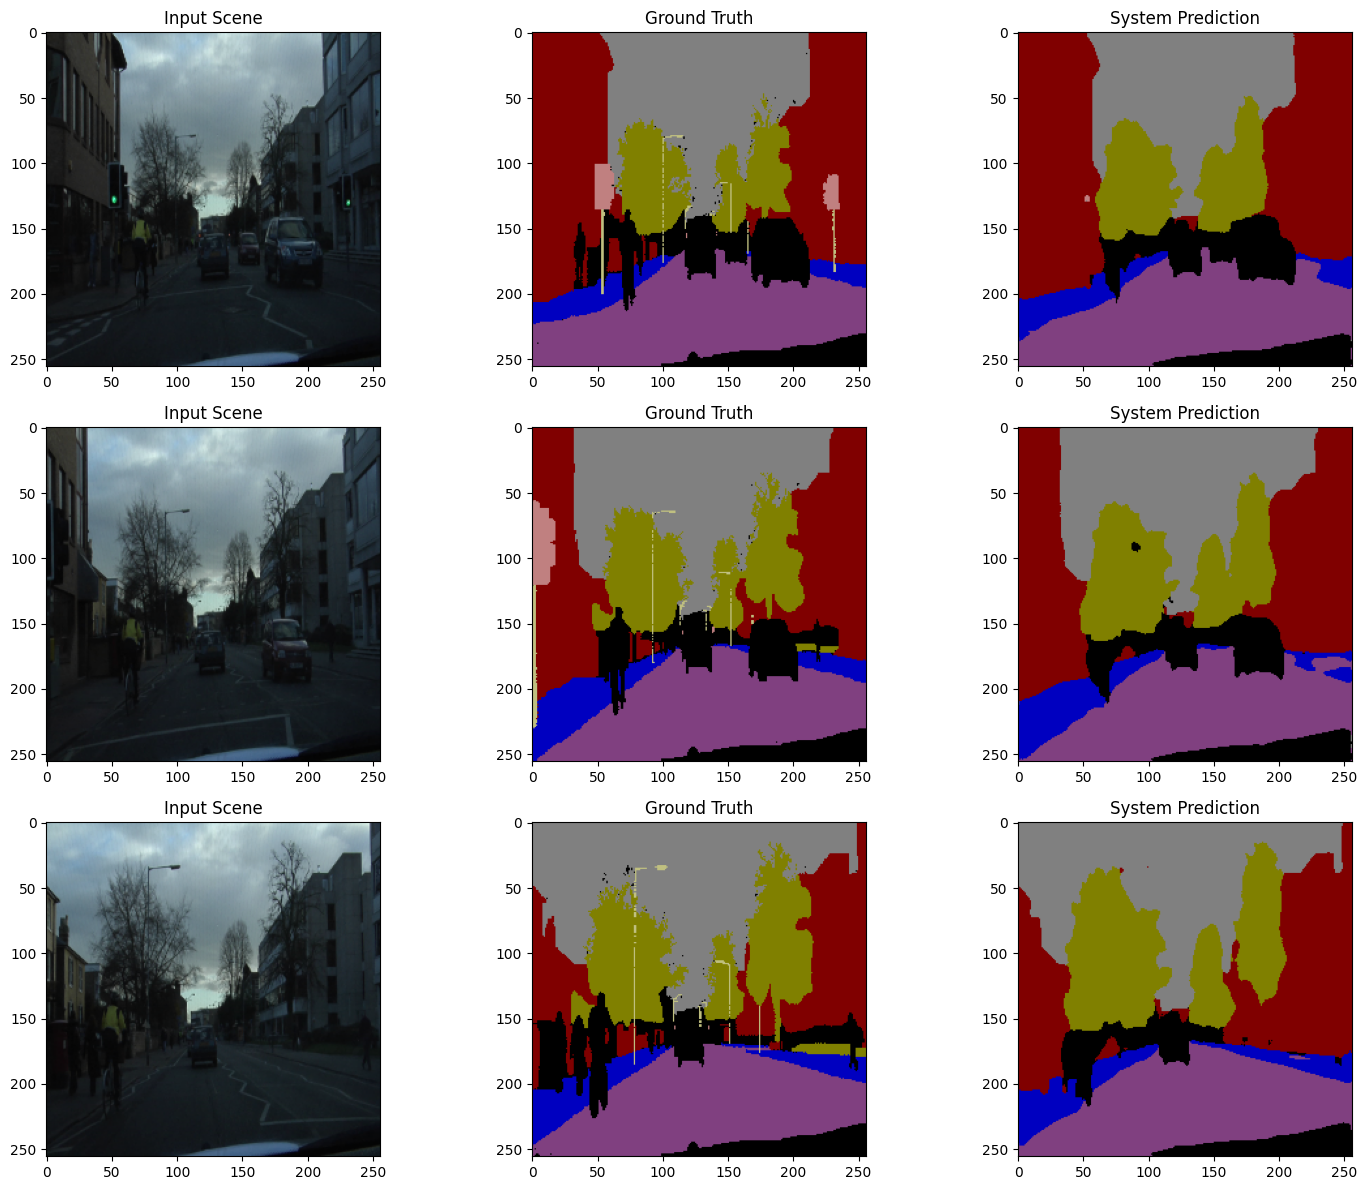

In [7]:
"""
VALIDATION: Qualitative performance analysis of 32-class segmentation.
METRIC: Visual overlap of predicted masks vs human annotation.
"""
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    preds = torch.argmax(model(images.to(DEVICE)), dim=1).cpu()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i in range(3):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
    axes[i, 0].imshow(img); axes[i, 0].set_title("Input Scene")
    axes[i, 1].imshow(color_label(masks[i].numpy())); axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(color_label(preds[i].numpy())); axes[i, 2].set_title("System Prediction")
plt.tight_layout()
plt.show()